LinearRegression (MSE)
w = 4.571428571428572
b = -6.0000000000000036

Ridge
w = 2.909090909090909
b = -0.18181818181818166

MAE-like (QuantileRegressor, q=0.5)
w = 2.0
b = 0.0


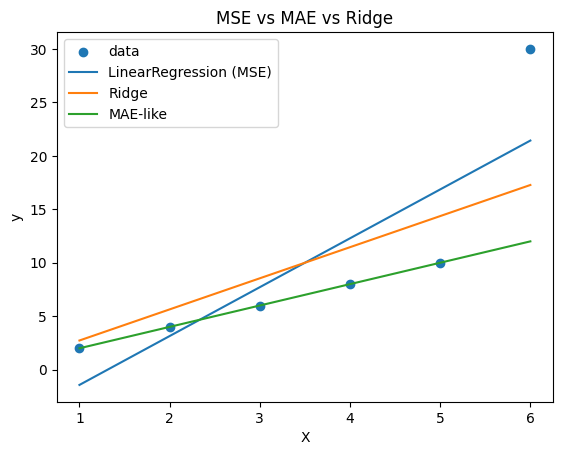

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.linear_model import QuantileRegressor

# 1. 建立資料
X = np.array([1, 2, 3, 4, 5, 6]).reshape(-1, 1)
y = np.array([2, 4, 6, 8, 10, 30])   # 最後一個故意放成 outlier

# 2. 建立模型
mse_model = LinearRegression()                # 用 MSE
ridge_model = Ridge(alpha=10.0)               # 也是平方誤差概念，但加上正則化
mae_model = QuantileRegressor(
    quantile=0.5,                             # 0.5 分位數 = median regression，接近 MAE
    alpha=0.0,
    solver="highs"
)

# 3. 訓練模型
mse_model.fit(X, y)
ridge_model.fit(X, y)
mae_model.fit(X, y)

# 4. 預測
x_line = np.linspace(1, 6, 100).reshape(-1, 1)
y_mse = mse_model.predict(x_line)
y_ridge = ridge_model.predict(x_line)
y_mae = mae_model.predict(x_line)

# 5. 印出參數
print("LinearRegression (MSE)")
print("w =", mse_model.coef_[0])
print("b =", mse_model.intercept_)
print()

print("Ridge")
print("w =", ridge_model.coef_[0])
print("b =", ridge_model.intercept_)
print()

print("MAE-like (QuantileRegressor, q=0.5)")
print("w =", mae_model.coef_[0])
print("b =", mae_model.intercept_)

# 6. 畫圖
plt.scatter(X, y, label="data")
plt.plot(x_line, y_mse, label="LinearRegression (MSE)")
plt.plot(x_line, y_ridge, label="Ridge")
plt.plot(x_line, y_mae, label="MAE-like")
plt.legend()
plt.xlabel("X")
plt.ylabel("y")
plt.title("MSE vs MAE vs Ridge")
plt.show()